# Chest X-Ray Classification Project
## CNN & MobileNetV2

## Step 0: Install Kaggle

In [ ]:
!pip install kaggle

## Step 0.1: Upload Kaggle API File

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"abdulsalamaldham","key":"e53b054e7589f29ad84a704547137de6"}'}

## Step 0.2: Configure Kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Step 0.3: Download Dataset

In [ ]:
!kaggle datasets download -d tolgadincer/labeled-chest-xray-images

Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other
100% 1.17G/1.17G [00:10<00:00, 120MB/s] 



## Step 0.4: Unzip Dataset

In [ ]:
!unzip -q labeled-chest-xray-images.zip

## Step 1: Import Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Step 2: Set Dataset Paths

In [ ]:
train_path = "/content/chest_xray/train"
test_path  = "/content/chest_xray/test"

## Step 3: Analyze Dataset

In [ ]:
train_normal = len(os.listdir('/content/chest_xray/train/NORMAL'))
train_pneumonia = len(os.listdir('/content/chest_xray/train/PNEUMONIA'))

test_normal = len(os.listdir('/content/chest_xray/test/NORMAL'))
test_pneumonia = len(os.listdir('/content/chest_xray/test/PNEUMONIA'))

print("Train NORMAL:", train_normal)
print("Train PNEUMONIA:", train_pneumonia)

print("Test NORMAL:", test_normal)
print("Test PNEUMONIA:", test_pneumonia)

Train NORMAL: 1349
Train PNEUMONIA: 3883
Test NORMAL: 234
Test PNEUMONIA: 390


## Step 4: Visualize Data Distribution

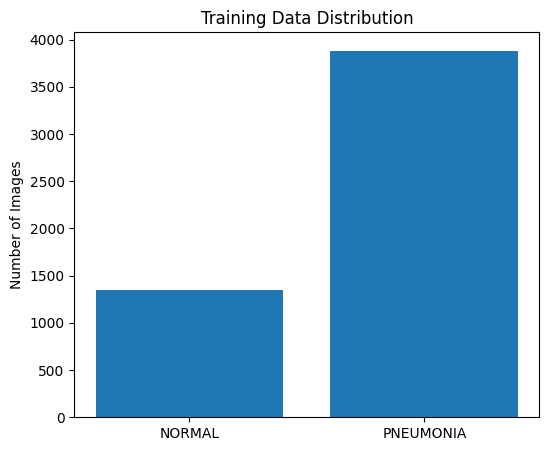

In [ ]:
classes = ['NORMAL', 'PNEUMONIA']
counts = [train_normal, train_pneumonia]

plt.figure(figsize=(6,5))
plt.bar(classes, counts)

plt.title("Training Data Distribution")
plt.ylabel("Number of Images")

plt.show()

## Step 5: Image Preprocessing (CNN)

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Step 6: Apply Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

## Step 7: Build CNN Model

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train CNN Model

In [ ]:
class_weight = {0: train_pneumonia/train_normal, 1: 1.0}

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 963ms/step - accuracy: 0.7473 - loss: 0.6883 - val_accuracy: 0.9426 - val_loss: 0.1692
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 744ms/step - accuracy: 0.9011 - loss: 0.3757 - val_accuracy: 0.9560 - val_loss: 0.1410
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 742ms/step - accuracy: 0.9276 - loss: 0.2675 - val_accuracy: 0.9368 - val_loss: 0.1559
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 737ms/step - accuracy: 0.9217 - loss: 0.2851 - val_accuracy: 0.9512 - val_loss: 0.1547
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 740ms/step - accuracy: 0.9255 - loss: 0.2603 - val_accuracy: 0.9541 - val_loss: 0.1315
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 744ms/step - accuracy: 0.9410 - loss: 0.2318 - val_accuracy: 0.9560 - val_loss: 0.1194
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 742ms/step - accuracy: 0.9393 - loss: 0.2357 - val_accuracy: 0.9598 - val_loss: 0.1276
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 733ms/step - accuracy: 0.9386 - loss: 

## Step 9: Evaluate CNN Model

In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_data)

print("\nCNN Test Accuracy:", cnn_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 316ms/step - accuracy: 0.8718 - loss: 0.3314

CNN Test Accuracy: 0.8717948794364929


## Step 10: Plot CNN Accuracy

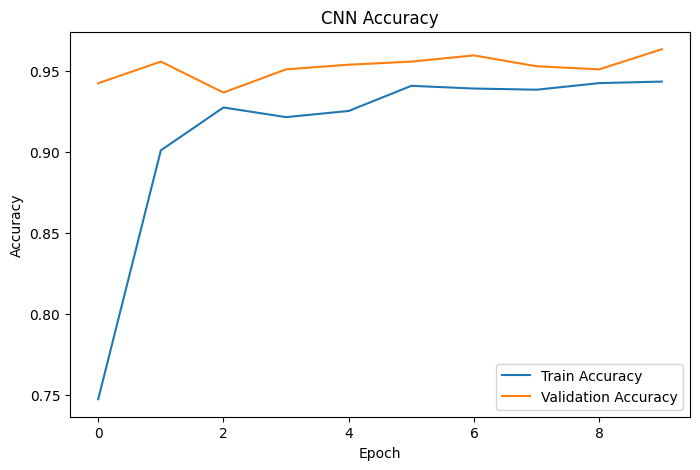

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Step 11: Plot CNN Loss

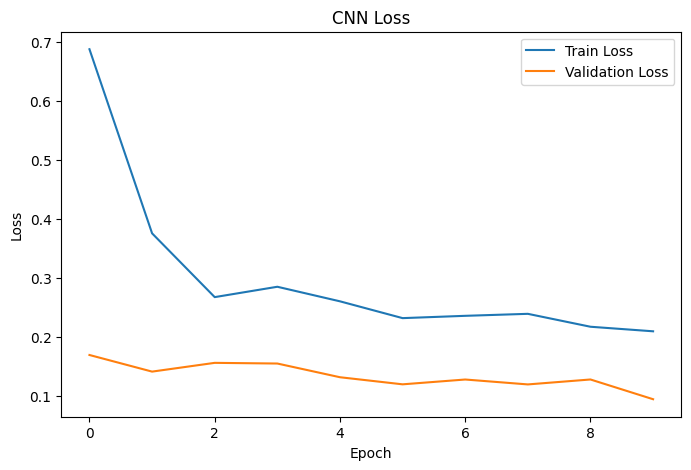

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Step 12: CNN Confusion Matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step


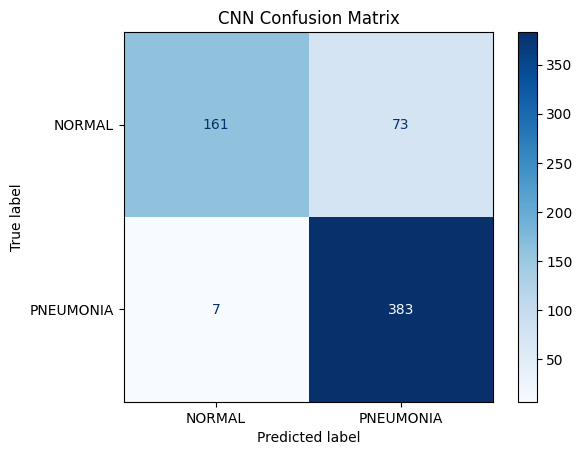

In [ ]:
y_pred = cnn_model.predict(test_data)
y_pred = np.round(y_pred)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['NORMAL', 'PNEUMONIA']
)

disp.plot(cmap='Blues')

plt.title("CNN Confusion Matrix")

plt.show()

## Step 13: Classification Report

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.69      0.80       234
   PNEUMONIA       0.84      0.98      0.91       390

    accuracy                           0.87       624
   macro avg       0.90      0.84      0.85       624
weighted avg       0.88      0.87      0.87       624



## Step 14: Preprocessing for MobileNetV2

In [ ]:
mob_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

mob_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

mob_train = mob_train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=32,
    class_mode='binary', subset='training'
)

mob_val = mob_train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=32,
    class_mode='binary', subset='validation'
)

mob_test = mob_test_datagen.flow_from_directory(
    test_path, target_size=(224,224), batch_size=32,
    class_mode='binary', shuffle=False
)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Step 15: Build MobileNetV2 Model

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 16: Train MobileNetV2

In [ ]:
mobilenet_history = mobilenet_model.fit(
    mob_train,
    validation_data=mob_val,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 143s 949ms/step - accuracy: 0.8405 - loss: 0.5124 - val_accuracy: 0.9311 - val_loss: 0.1753
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 724ms/step - accuracy: 0.9181 - loss: 0.3010 - val_accuracy: 0.9378 - val_loss: 0.1532
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 731ms/step - accuracy: 0.9329 - loss: 0.2481 - val_accuracy: 0.9292 - val_loss: 0.1475
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 719ms/step - accuracy: 0.9424 - loss: 0.2153 - val_accuracy: 0.9426 - val_loss: 0.1313


## Step 17: Evaluate MobileNetV2

In [ ]:
mobile_loss, mobile_acc = mobilenet_model.evaluate(mob_test)

print("\nMobileNetV2 Test Accuracy:", mobile_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 827ms/step - accuracy: 0.8638 - loss: 0.2943

MobileNetV2 Test Accuracy: 0.8637820482254028


## Step 18: Plot MobileNetV2 Accuracy

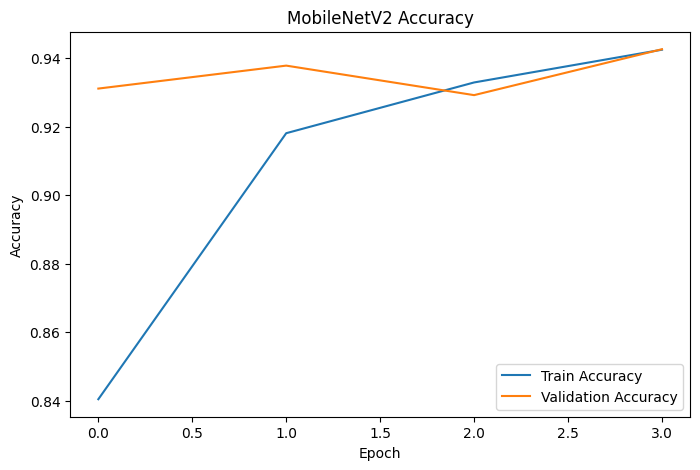

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Step 19: Final Results Comparison

In [ ]:
print("\n========== FINAL RESULTS ==========")
print(f"CNN Accuracy: {cnn_acc:.4f}")
print(f"MobileNetV2 Accuracy: {mobile_acc:.4f}")


========== FINAL RESULTS ==========
CNN Accuracy: 0.8718
MobileNetV2 Accuracy: 0.8638


## Step 20: Compare Models Using Graph

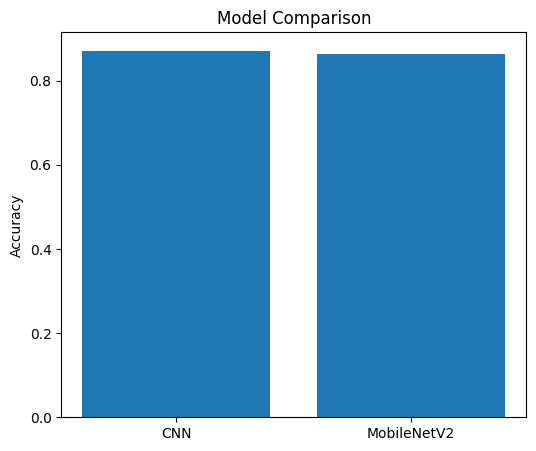

In [ ]:
models = ['CNN', 'MobileNetV2']
accuracies = [cnn_acc, mobile_acc]

plt.figure(figsize=(6,5))
plt.bar(models, accuracies)

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.show()